In [1]:
import json, pickle, warnings, time
from pathlib import Path
from datetime import datetime, timedelta
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm
 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights
from torchvision.datasets import ImageFolder
 
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image
import cv2
 
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.calibration import CalibratedClassifierCV
from sklearn.isotonic import IsotonicRegression
 
warnings.filterwarnings('ignore')
 
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
 
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")
 
# ── All files in one folder ──
BASE_DIR = Path('.')    # <-- change if your files are elsewhere
 
# Verify all required files exist
required = [
    'best_model_v2.pth', 'class_names.json',
    'best_lstm.pth', 'lstm_config.json',
    'weather_scaler.pkl', 'weather_features.csv', 'dcws_scores.csv'
]
missing = [f for f in required if not (BASE_DIR / f).exists()]
if missing:
    print(f"MISSING FILES: {missing}")
    raise SystemExit("Fix missing files before continuing.")
else:
    print("All required files found ✓")


Device : cuda
All required files found ✓


In [ ]:
with open(BASE_DIR / 'class_names.json') as f:
    CLASS_NAMES = json.load(f)
NUM_CLASSES = len(CLASS_NAMES)
CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}
print(f"Classes : {NUM_CLASSES}")
 
IMG_SIZE = 380
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]
 
val_transform = A.Compose([
    A.Resize(height=IMG_SIZE, width=IMG_SIZE),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])
 
 
class CropDiseaseClassifier(nn.Module):
    """EfficientNet-B4 — identical architecture to Increment 1."""
    def __init__(self, num_classes=38, dropout=0.4):
        super().__init__()
        backbone        = efficientnet_b4(weights=EfficientNet_B4_Weights.IMAGENET1K_V1)
        self.features   = backbone.features
        self.avgpool    = backbone.avgpool
        self.embedding  = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(1792, 512),
            nn.ReLU(),
        )
        self.classifier = nn.Linear(512, num_classes)
        self._feat_maps  = None
        self._feat_grads = None
        self.features[-1].register_forward_hook(self._save_maps)
        self.features[-1].register_full_backward_hook(self._save_grads)
 
    def _save_maps(self, m, i, o):  self._feat_maps  = o
    def _save_grads(self, m, i, o): self._feat_grads = o[0]
 
    def forward(self, x):
        x = self.features(x); x = self.avgpool(x)
        x = torch.flatten(x, 1)
        emb = self.embedding(x)
        return self.classifier(emb)
 
    def get_embedding(self, x):
        with torch.no_grad():
            x = self.features(x); x = self.avgpool(x)
            x = torch.flatten(x, 1)
            return self.embedding(x)
 
    def grad_cam(self, image_tensor, class_idx=None):
        self.eval()
        x      = image_tensor.unsqueeze(0).to(DEVICE)
        logits = self.forward(x)
        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()
        self.zero_grad()
        logits[0, class_idx].backward()
        weights = self._feat_grads.mean(dim=[2, 3], keepdim=True)
        cam     = (weights * self._feat_maps).sum(dim=1).squeeze()
        cam     = torch.clamp(cam, min=0)
        cam     = cam / (cam.max() + 1e-8)
        conf    = logits.softmax(dim=1)[0, class_idx].item()
        return cam.detach().cpu().numpy(), class_idx, conf
 
 
# Load CNN — frozen
cnn_model = CropDiseaseClassifier(num_classes=NUM_CLASSES).to(DEVICE)
cnn_model.load_state_dict(
    torch.load(BASE_DIR / 'best_model_v2.pth', map_location=DEVICE)
)
cnn_model.eval()
for p in cnn_model.parameters():
    p.requires_grad = False
print("CNN loaded and frozen ✓")
 
# Sanity check embedding
dummy_img = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
cnn_emb   = cnn_model.get_embedding(dummy_img)
print(f"CNN embedding shape : {cnn_emb.shape}")   # (2, 512)


Classes : 38
CNN loaded and frozen ✓
CNN embedding shape : torch.Size([2, 512])


In [3]:
with open(BASE_DIR / 'lstm_config.json') as f:
    lstm_cfg = json.load(f)
 
WEATHER_FEATURES = lstm_cfg['weather_features']
DISEASE_CLASSES  = lstm_cfg['disease_classes']
LOOKBACK         = lstm_cfg['lookback']
FORECAST         = lstm_cfg['forecast_steps']
N_DISEASES       = lstm_cfg['n_diseases']
N_FEATURES       = len(WEATHER_FEATURES)
 
print(f"LSTM config loaded  ✓")
print(f"  Weather features : {N_FEATURES}")
print(f"  Disease classes  : {N_DISEASES}")
print(f"  Lookback         : {LOOKBACK} days")
print(f"  Forecast         : {FORECAST} days")
 
 
class TemporalAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim * 2, 1)
 
    def forward(self, lstm_out):
        scores  = self.attn(lstm_out).squeeze(-1)
        weights = torch.softmax(scores, dim=1)
        context = (weights.unsqueeze(-1) * lstm_out).sum(dim=1)
        return context, weights
 
 
class WeatherLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2,
                 forecast_steps=7, n_diseases=26, dropout=0.3):
        super().__init__()
        self.hidden_dim     = hidden_dim
        self.forecast_steps = forecast_steps
        self.n_diseases     = n_diseases
        self.lstm = nn.LSTM(
            input_size=input_dim, hidden_size=hidden_dim,
            num_layers=num_layers, batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.attention = TemporalAttention(hidden_dim)
        self.dropout   = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 256), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, forecast_steps * n_diseases),
            nn.Sigmoid()
        )
 
    def forward(self, x):
        lstm_out, _      = self.lstm(x)
        context, weights = self.attention(lstm_out)
        context          = self.dropout(context)
        out              = self.fc(context)
        out              = out.view(-1, self.forecast_steps, self.n_diseases)
        return out, context, weights
 
    def get_weather_context(self, x):
        with torch.no_grad():
            lstm_out, _ = self.lstm(x)
            context, _  = self.attention(lstm_out)
            return context   # (batch, 256)
 
 
lstm_model = WeatherLSTM(
    input_dim      = N_FEATURES,
    hidden_dim     = lstm_cfg['hidden_dim'],
    num_layers     = lstm_cfg['num_layers'],
    forecast_steps = FORECAST,
    n_diseases     = N_DISEASES,
    dropout        = lstm_cfg['dropout']
).to(DEVICE)
 
lstm_model.load_state_dict(
    torch.load(BASE_DIR / 'best_lstm.pth', map_location=DEVICE)
)
lstm_model.eval()
for p in lstm_model.parameters():
    p.requires_grad = False
print("LSTM loaded and frozen ✓")
 
# Sanity check context vector
dummy_wx  = torch.randn(2, LOOKBACK, N_FEATURES).to(DEVICE)
wx_ctx    = lstm_model.get_weather_context(dummy_wx)
print(f"LSTM context shape  : {wx_ctx.shape}")   # (2, 256)
 
# Load weather scaler
with open(BASE_DIR / 'weather_scaler.pkl', 'rb') as f:
    weather_scaler = pickle.load(f)
print("Weather scaler loaded ✓")

LSTM config loaded  ✓
  Weather features : 19
  Disease classes  : 26
  Lookback         : 30 days
  Forecast         : 7 days
LSTM loaded and frozen ✓
LSTM context shape  : torch.Size([2, 256])
Weather scaler loaded ✓


In [4]:
CROP_TYPES = [
    'Apple', 'Blueberry', 'Cherry', 'Corn', 'Grape', 'Orange',
    'Peach', 'Pepper', 'Potato', 'Raspberry', 'Soybean',
    'Squash', 'Strawberry', 'Tomato'
]
GROWTH_STAGES = [
    'seedling', 'vegetative', 'flowering', 'fruiting', 'mature'
]
 
CROP_TO_IDX   = {c: i for i, c in enumerate(CROP_TYPES)}
STAGE_TO_IDX  = {s: i for i, s in enumerate(GROWTH_STAGES)}
 
META_DIM = len(CROP_TYPES) + len(GROWTH_STAGES) + 2   # +2 for normalized fields
 
 
def encode_metadata(crop_type, growth_stage,
                    days_since_planting, days_to_harvest):
    """
    Encodes crop metadata into a fixed 21-d vector.
    One-hot crop type + one-hot growth stage + 2 normalized scalars.
    """
    vec = np.zeros(META_DIM, dtype=np.float32)
 
    # One-hot crop type (14-d)
    if crop_type in CROP_TO_IDX:
        vec[CROP_TO_IDX[crop_type]] = 1.0
 
    # One-hot growth stage (5-d)
    offset = len(CROP_TYPES)
    if growth_stage in STAGE_TO_IDX:
        vec[offset + STAGE_TO_IDX[growth_stage]] = 1.0
 
    # Normalized scalars
    vec[offset + len(GROWTH_STAGES)]     = min(days_since_planting / 180, 1.0)
    vec[offset + len(GROWTH_STAGES) + 1] = min(days_to_harvest / 90, 1.0)
 
    return vec
 
 
# Update META_DIM with actual value
META_DIM = len(CROP_TYPES) + len(GROWTH_STAGES) + 2
FUSION_INPUT_DIM = 512 + 256 + META_DIM   # CNN + LSTM + metadata
print(f"Metadata vector dim : {META_DIM}")
print(f"Fusion input dim    : {FUSION_INPUT_DIM}")   # 512+256+21 = 789
 
# Test encoder
sample_meta = encode_metadata('Tomato', 'fruiting', 75, 20)
print(f"Sample metadata vec : shape={sample_meta.shape}  "
      f"sum={sample_meta.sum():.1f}")


Metadata vector dim : 21
Fusion input dim    : 789
Sample metadata vec : shape=(21,)  sum=2.6


In [38]:
PV_ROOT    = Path('plantvillage dataset/color')   # <-- change if your PV images are elsewhere
N_SAMPLES  = 8000    # increased from 5000
BATCH_SIZE = 64

# Load weather data
weather_df = pd.read_csv(BASE_DIR / 'weather_features.csv',
                          index_col=0, parse_dates=True)
dcws_df    = pd.read_csv(BASE_DIR / 'dcws_scores.csv',
                          index_col=0, parse_dates=True)
common_idx  = weather_df.index.intersection(dcws_df.index)
weather_df  = weather_df.loc[common_idx]
dcws_df     = dcws_df.loc[common_idx]

print(f"Generating {N_SAMPLES} fusion training samples (fixed)...")

# ── Step 1: Extract CNN embeddings + confidences ──
class EmbeddingDataset(Dataset):
    def __init__(self, pv_root, n_samples, transform):
        dataset  = ImageFolder(root=str(pv_root))
        all_idx  = list(range(len(dataset)))
        chosen   = np.random.choice(all_idx, size=n_samples, replace=False)
        self.samples   = [dataset.samples[i] for i in chosen]
        self.transform = transform

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img  = np.array(Image.open(path).convert('RGB'))
        img  = self.transform(image=img)['image']
        return img, label, path


emb_dataset = EmbeddingDataset(PV_ROOT, N_SAMPLES, val_transform)
emb_loader  = DataLoader(emb_dataset, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0)

print("Extracting CNN embeddings + confidences...")
all_cnn_embs   = []
all_labels     = []
all_cnn_confs  = []      # NEW: track per-class confidence
all_cnn_probs  = []      # NEW: full softmax distribution

cnn_model.eval()
with torch.no_grad():
    for imgs, labels, _ in tqdm(emb_loader, desc='  CNN'):
        imgs_dev = imgs.to(DEVICE)
        embs     = cnn_model.get_embedding(imgs_dev)
        logits   = cnn_model(imgs_dev)
        probs    = logits.softmax(dim=1)
        confs    = probs.max(dim=1).values

        all_cnn_embs.append(embs.cpu().numpy())
        all_labels.extend(labels.tolist())
        all_cnn_confs.extend(confs.cpu().tolist())
        all_cnn_probs.append(probs.cpu().numpy())

cnn_embeddings = np.concatenate(all_cnn_embs,  axis=0)   # (N, 512)
cnn_probs_all  = np.concatenate(all_cnn_probs, axis=0)   # (N, 38)
cnn_labels     = np.array(all_labels)
cnn_confs      = np.array(all_cnn_confs)

print(f"CNN embeddings  : {cnn_embeddings.shape}")
print(f"CNN confidence  : mean={cnn_confs.mean():.2f}  "
      f"min={cnn_confs.min():.2f}  max={cnn_confs.max():.2f}")

# ── Step 2: Oversample high-confidence CNN samples ──
# FIX 3: Ensure model sees enough cases where CNN should dominate
low_conf_idx  = np.where(cnn_confs < 0.60)[0]
mid_conf_idx  = np.where((cnn_confs >= 0.60) & (cnn_confs < 0.85))[0]
high_conf_idx = np.where(cnn_confs >= 0.85)[0]

print(f"\nConfidence distribution:")
print(f"  Low  (<60%)  : {len(low_conf_idx):,}")
print(f"  Mid  (60-85%): {len(mid_conf_idx):,}")
print(f"  High (>85%)  : {len(high_conf_idx):,}")

# Oversample high confidence to 40% of dataset
target_high = int(N_SAMPLES * 0.40)
target_mid  = int(N_SAMPLES * 0.35)
target_low  = N_SAMPLES - target_high - target_mid

sampled_high = np.random.choice(high_conf_idx,
                                 size=min(target_high, len(high_conf_idx)),
                                 replace=len(high_conf_idx) < target_high)
sampled_mid  = np.random.choice(mid_conf_idx,
                                 size=min(target_mid, len(mid_conf_idx)),
                                 replace=len(mid_conf_idx) < target_mid)
sampled_low  = np.random.choice(low_conf_idx,
                                 size=min(target_low, len(low_conf_idx)),
                                 replace=len(low_conf_idx) < target_low)

balanced_idx = np.concatenate([sampled_high, sampled_mid, sampled_low])
np.random.shuffle(balanced_idx)

cnn_embeddings = cnn_embeddings[balanced_idx]
cnn_probs_all  = cnn_probs_all[balanced_idx]
cnn_labels     = cnn_labels[balanced_idx]
cnn_confs      = cnn_confs[balanced_idx]

print(f"\nAfter balancing: {len(balanced_idx):,} samples")
print(f"  High conf (>85%): {(cnn_confs >= 0.85).sum():,}  "
      f"({(cnn_confs >= 0.85).mean():.0%})")


# ── Step 3: Extract LSTM context vectors ──
print("\nExtracting LSTM context vectors...")
feat_array  = weather_df[WEATHER_FEATURES].values.astype(np.float32)
feat_norm   = weather_scaler.transform(feat_array)
max_start   = len(feat_norm) - LOOKBACK - FORECAST
wx_indices  = np.random.choice(max_start, size=len(balanced_idx), replace=True)

all_wx_contexts = []
all_dcws_labels = []

lstm_model.eval()
with torch.no_grad():
    for i in tqdm(range(0, len(balanced_idx), BATCH_SIZE), desc='  LSTM'):
        batch_idx = wx_indices[i:i+BATCH_SIZE]
        batch_x   = np.stack([feat_norm[j:j+LOOKBACK] for j in batch_idx])
        batch_x   = torch.tensor(batch_x).to(DEVICE)
        ctx       = lstm_model.get_weather_context(batch_x)
        all_wx_contexts.append(ctx.cpu().numpy())

        for j in batch_idx:
            dcws_window = dcws_df[DISEASE_CLASSES].iloc[j:j+FORECAST].mean().values
            all_dcws_labels.append(dcws_window)

wx_contexts = np.concatenate(all_wx_contexts, axis=0)   # (N, 256)
dcws_labels = np.array(all_dcws_labels)                  # (N, 26)
print(f"LSTM contexts   : {wx_contexts.shape}")


# ── Step 4: Metadata ──
print("Sampling crop metadata...")
crop_map = {
    'Apple': 'Apple', 'Blueberry': 'Blueberry',
    'Cherry_(including_sour)': 'Cherry',
    'Corn_(maize)': 'Corn', 'Grape': 'Grape',
    'Orange': 'Orange', 'Peach': 'Peach',
    'Pepper,_bell': 'Pepper', 'Potato': 'Potato',
    'Raspberry': 'Raspberry', 'Soybean': 'Soybean',
    'Squash': 'Squash', 'Strawberry': 'Strawberry',
    'Tomato': 'Tomato',
}
meta_vectors = []
for label in cnn_labels:
    class_name = CLASS_NAMES[label]
    crop_raw   = class_name.split('___')[0]
    crop       = crop_map.get(crop_raw, 'Tomato')
    stage      = np.random.choice(GROWTH_STAGES)
    dsp        = np.random.randint(10, 150)
    dth        = np.random.randint(5, 90)
    meta_vectors.append(encode_metadata(crop, stage, dsp, dth))

meta_array = np.array(meta_vectors)   # (N, 21)

# ── Step 5: Build FIXED fusion targets ──
# FIX 1: CNN weight = f(confidence) — high confidence CNN dominates
# FIX 2: CNN signal is a full 26-d vector, not just one class
#
# CNN signal vector: for each of the 26 disease classes,
#   use the CNN's softmax probability for that class (mapped from 38→26)
# This means the CNN's full probability distribution contributes,
# not just the argmax class.

print("\nBuilding fixed fusion targets...")

# Map CNN 38-class probs → 26 disease class probs
cnn_disease_probs = np.zeros((len(cnn_labels), len(DISEASE_CLASSES)),
                              dtype=np.float32)
for sample_i in range(len(cnn_labels)):
    for class_38_i, cname in enumerate(CLASS_NAMES):
        if cname in DISEASE_CLASSES:
            disease_j = DISEASE_CLASSES.index(cname)
            cnn_disease_probs[sample_i, disease_j] = \
                cnn_probs_all[sample_i, class_38_i]

# CNN weight per sample = confidence ^ 0.5
# (square root so even moderate confidence contributes meaningfully)
# High conf (95%) → weight 0.97  → CNN dominates
# Mid  conf (60%) → weight 0.77  → balanced
# Low  conf (30%) → weight 0.55  → weather dominates
cnn_weights = (cnn_confs ** 0.5).reshape(-1, 1)   # (N, 1)

# Fused target: weighted combination
y_fusion = (cnn_weights * cnn_disease_probs +
            (1 - cnn_weights) * dcws_labels)
y_fusion = np.clip(y_fusion, 0, 1).astype(np.float32)

# Build feature matrix
X_fusion = np.concatenate([cnn_embeddings, wx_contexts, meta_array],
                           axis=1).astype(np.float32)

print(f"\nFusion feature matrix : {X_fusion.shape}")
print(f"Fusion target matrix  : {y_fusion.shape}")

# Verify CNN signal is actually present
high_idx   = np.where(cnn_confs >= 0.85)[0]
low_idx    = np.where(cnn_confs < 0.60)[0]
print(f"\nTarget sanity check:")
print(f"  High CNN conf samples — mean target: "
      f"{y_fusion[high_idx].mean():.3f}  "
      f"(CNN should dominate)")
print(f"  Low  CNN conf samples — mean target: "
      f"{y_fusion[low_idx].mean():.3f}  "
      f"(weather should dominate)")
print(f"\nSynthetic data generation complete ✓")

Generating 8000 fusion training samples (fixed)...
Extracting CNN embeddings + confidences...


  CNN: 100%|██████████| 125/125 [06:58<00:00,  3.35s/it]


CNN embeddings  : (8000, 512)
CNN confidence  : mean=0.88  min=0.17  max=1.00

Confidence distribution:
  Low  (<60%)  : 184
  Mid  (60-85%): 1,596
  High (>85%)  : 6,220

After balancing: 4,980 samples
  High conf (>85%): 3,200  (64%)

Extracting LSTM context vectors...


  LSTM: 100%|██████████| 78/78 [00:18<00:00,  4.12it/s]


LSTM contexts   : (4980, 256)
Sampling crop metadata...

Building fixed fusion targets...

Fusion feature matrix : (4980, 789)
Fusion target matrix  : (4980, 26)

Target sanity check:
  High CNN conf samples — mean target: 0.050  (CNN should dominate)
  Low  CNN conf samples — mean target: 0.185  (weather should dominate)

Synthetic data generation complete ✓


In [43]:
import os, torch, torch.nn as nn

# Force delete old checkpoint
for f in ['best_fusion.pth', 'fusion_config.json', 'calibrators.pkl']:
    if os.path.exists(f):
        os.remove(f)
        print(f"Deleted {f}")

# Verify it's gone
print("best_fusion.pth exists:", os.path.exists('best_fusion.pth'))

best_fusion.pth exists: False


In [47]:
CNN_DIM    = 512
WEATHER_DIM = 256
META_DIM_   = META_DIM   # 21
N_HEADS     = 8          # attention heads


class CrossAttentionFusion(nn.Module):
    """
    Cross-attention fusion:
      Query  = CNN embedding  (what disease did we see?)
      Key    = Weather context (what are conditions like?)
      Value  = Weather context (extract relevant weather info)

    This lets the model ask: "given what the CNN detected,
    which aspects of the current weather are most relevant?"
    """
    def __init__(self, cnn_dim=512, weather_dim=256,
                 meta_dim=21, n_diseases=26,
                 attn_dim=256, n_heads=8, dropout=0.3):
        super().__init__()

        # Project CNN and weather to common attention dimension
        self.cnn_proj     = nn.Linear(cnn_dim, attn_dim)
        self.weather_proj = nn.Linear(weather_dim, attn_dim)

        # Multi-head cross-attention: CNN queries weather
        self.cross_attn = nn.MultiheadAttention(
            embed_dim   = attn_dim,
            num_heads   = n_heads,
            dropout     = dropout,
            batch_first = True,
        )
        self.attn_norm = nn.LayerNorm(attn_dim)

        # Self-attention within CNN stream
        self.self_attn = nn.MultiheadAttention(
            embed_dim   = attn_dim,
            num_heads   = n_heads,
            dropout     = dropout,
            batch_first = True,
        )
        self.self_norm = nn.LayerNorm(attn_dim)

        # Metadata projection
        self.meta_proj = nn.Sequential(
            nn.Linear(meta_dim, 64),
            nn.LayerNorm(64),
            nn.GELU(),
        )

        # Final fusion head
        # Input: attn_dim (cross) + attn_dim (self) + 64 (meta)
        fusion_dim = attn_dim + attn_dim + 64
        self.fusion_head = nn.Sequential(
            nn.Linear(fusion_dim, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, n_diseases),
            # No sigmoid — BCEWithLogitsLoss handles it
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        """
        x: (batch, 789) — concatenated [CNN(512), weather(256), meta(21)]
        """
        # Split input streams
        cnn_feat     = x[:, :CNN_DIM]                          # (B, 512)
        weather_feat = x[:, CNN_DIM:CNN_DIM+WEATHER_DIM]       # (B, 256)
        meta_feat    = x[:, CNN_DIM+WEATHER_DIM:]              # (B, 21)

        # Project to attention dimension — add seq_len=1 for attention
        cnn_q     = self.cnn_proj(cnn_feat).unsqueeze(1)       # (B, 1, 256)
        weather_k = self.weather_proj(weather_feat).unsqueeze(1)  # (B, 1, 256)
        weather_v = weather_k

        # Cross-attention: CNN queries weather context
        cross_out, cross_weights = self.cross_attn(
            query = cnn_q,
            key   = weather_k,
            value = weather_v,
        )   # (B, 1, 256)
        cross_out = self.attn_norm(cross_out + cnn_q)   # residual
        cross_out = cross_out.squeeze(1)                # (B, 256)

        # Self-attention within CNN stream (captures disease relationships)
        self_out, _ = self.self_attn(cnn_q, cnn_q, cnn_q)
        self_out    = self.self_norm(self_out + cnn_q)
        self_out    = self_out.squeeze(1)               # (B, 256)

        # Metadata stream
        meta_out = self.meta_proj(meta_feat)            # (B, 64)

        # Concatenate all streams
        fused = torch.cat([cross_out, self_out, meta_out], dim=1)  # (B, 576)
        fused = self.dropout(fused)

        return self.fusion_head(fused)                  # (B, 26)

    def predict_with_uncertainty(self, x, n_passes=50):
        """
        MC Dropout inference — works with batch size 1.
        LayerNorm handles single samples correctly.
        """
        self.eval()
        # Re-enable only dropout layers
        for m in self.modules():
            if isinstance(m, nn.Dropout):
                m.train()

        with torch.no_grad():
            preds = torch.stack([
                torch.sigmoid(self.forward(x))
                for _ in range(n_passes)
            ])
        return preds.mean(dim=0), preds.std(dim=0)


# Remove old checkpoint if exists
import os
for f in ['best_fusion.pth']:
    if os.path.exists(f):
        os.remove(f)
        print(f"Removed old {f}")

fusion_model = CrossAttentionFusion(
    cnn_dim=CNN_DIM, weather_dim=WEATHER_DIM, meta_dim=META_DIM,
    n_diseases=N_DISEASES, attn_dim=256, n_heads=8, dropout=0.3
).to(DEVICE)

# Sanity check
dummy = torch.randn(4, FUSION_INPUT_DIM).to(DEVICE)
out   = fusion_model(dummy)
print(f"Output shape: {out.shape}")

keys = list(fusion_model.state_dict().keys())
print("First 5 keys:", keys[:5])

total_params = sum(p.numel() for p in fusion_model.parameters())
print(f"Fusion model params : {total_params:,}")

# Verify no BatchNorm
for name, module in fusion_model.named_modules():
    if isinstance(module, nn.BatchNorm1d):
        print(f"WARNING: BatchNorm at {name}")
print("Architecture check passed — no BatchNorm ✓")
print("Cross-attention fusion model ready ✓")

Removed old best_fusion.pth
Output shape: torch.Size([4, 26])
First 5 keys: ['cnn_proj.weight', 'cnn_proj.bias', 'weather_proj.weight', 'weather_proj.bias', 'cross_attn.in_proj_weight']
Fusion model params : 1,160,986
Architecture check passed — no BatchNorm ✓
Cross-attention fusion model ready ✓


In [45]:
# Run this in a new cell — clears the old checkpoint
import os
if os.path.exists('best_fusion.pth'):
    os.remove('best_fusion.pth')
    print("Deleted old best_fusion.pth")

# Rebuild model fresh with LayerNorm
fusion_model = FusionMLP(
    input_dim   = FUSION_INPUT_DIM,
    hidden_dims = (512, 256, 128),
    n_diseases  = N_DISEASES,
    dropout     = 0.3
).to(DEVICE)

# Confirm no BatchNorm in model
for name, module in fusion_model.named_modules():
    if isinstance(module, nn.BatchNorm1d):
        print(f"WARNING: BatchNorm still present at {name}")
        
print("Model layers:")
for name, module in fusion_model.named_modules():
    if not isinstance(module, nn.Sequential):
        print(f"  {name}: {type(module).__name__}")

Model layers:
  : FusionMLP
  backbone.0: Linear
  backbone.1: LayerNorm
  backbone.2: GELU
  backbone.3: Dropout
  backbone.4: Linear
  backbone.5: LayerNorm
  backbone.6: GELU
  backbone.7: Dropout
  backbone.8: Linear
  backbone.9: LayerNorm
  backbone.10: GELU
  backbone.11: Dropout
  head: Linear


In [48]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_fusion, y_fusion, test_size=0.30,
    random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50,
    random_state=SEED
)
print(f"Fusion train : {X_train.shape}")
print(f"Fusion val   : {X_val.shape}")
print(f"Fusion test  : {X_test.shape}")


class FusionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self): return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


FUSION_BATCH   = 128
train_loader_f = DataLoader(FusionDataset(X_train, y_train),
                             batch_size=FUSION_BATCH, shuffle=True)
val_loader_f   = DataLoader(FusionDataset(X_val, y_val),
                             batch_size=FUSION_BATCH, shuffle=False)
test_loader_f  = DataLoader(FusionDataset(X_test, y_test),
                             batch_size=FUSION_BATCH, shuffle=False)

# BCEWithLogitsLoss is autocast-safe (combines sigmoid + BCE internally)
criterion_f  = nn.BCEWithLogitsLoss()
optimizer_f  = optim.Adam(fusion_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_f  = optim.lr_scheduler.CosineAnnealingLR(optimizer_f, T_max=50)
scaler_amp   = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))

best_val_loss = float('inf')
patience, no_improve = 8, 0
history_f = {'train_loss': [], 'val_loss': [], 'val_mae': []}

EPOCHS_F = 50
print(f"\n{'='*60}")
print("FUSION MLP TRAINING — CNN + LSTM + Metadata")
print(f"{'='*60}")

for epoch in range(1, EPOCHS_F + 1):
    # Train
    fusion_model.train()
    tr_loss, tr_total = 0.0, 0
    for X_b, y_b in train_loader_f:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        optimizer_f.zero_grad()
        with torch.autocast(device_type=DEVICE.type,
                            dtype=torch.float16,
                            enabled=(DEVICE.type == 'cuda')):
            pred = fusion_model(X_b)
            loss = criterion_f(pred, y_b)   # sigmoid applied internally
        scaler_amp.scale(loss).backward()
        scaler_amp.step(optimizer_f)
        scaler_amp.update()
        tr_loss  += loss.item() * X_b.size(0)
        tr_total += X_b.size(0)
    tr_loss /= tr_total

    # Validate
    fusion_model.eval()
    vl_loss, vl_mae, vl_total = 0.0, 0.0, 0
    with torch.no_grad():
        for X_b, y_b in val_loader_f:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            pred      = fusion_model(X_b)
            loss      = criterion_f(pred, y_b)
            vl_loss  += loss.item() * X_b.size(0)
            # Apply sigmoid to get probabilities for MAE calculation
            vl_mae   += (torch.sigmoid(pred) - y_b).abs().mean().item() * X_b.size(0)
            vl_total += X_b.size(0)
    vl_loss /= vl_total
    vl_mae  /= vl_total

    scheduler_f.step()
    history_f['train_loss'].append(tr_loss)
    history_f['val_loss'].append(vl_loss)
    history_f['val_mae'].append(vl_mae)

    marker = ''
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        no_improve    = 0
        torch.save(fusion_model.state_dict(), 'best_fusion.pth')
        marker = '  ← saved'
    else:
        no_improve += 1

    if epoch % 5 == 0 or no_improve == 0:
        print(f"Epoch {epoch:03d}/{EPOCHS_F}  "
              f"train {tr_loss:.5f}  |  "
              f"val {vl_loss:.5f}  MAE {vl_mae:.4f}  "
              f"lr {scheduler_f.get_last_lr()[0]:.1e}{marker}")

    if no_improve >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

print(f"\nFusion training complete. Best val loss: {best_val_loss:.5f}")

Fusion train : (3486, 789)
Fusion val   : (747, 789)
Fusion test  : (747, 789)

FUSION MLP TRAINING — CNN + LSTM + Metadata
Epoch 001/50  train 0.29979  |  val 0.23424  MAE 0.0516  lr 1.0e-03  ← saved
Epoch 002/50  train 0.23316  |  val 0.20829  MAE 0.0483  lr 1.0e-03  ← saved
Epoch 003/50  train 0.21068  |  val 0.19116  MAE 0.0385  lr 9.9e-04  ← saved
Epoch 004/50  train 0.19979  |  val 0.18515  MAE 0.0318  lr 9.8e-04  ← saved
Epoch 005/50  train 0.19442  |  val 0.18167  MAE 0.0279  lr 9.8e-04  ← saved
Epoch 006/50  train 0.19047  |  val 0.18122  MAE 0.0263  lr 9.6e-04  ← saved
Epoch 007/50  train 0.18908  |  val 0.17821  MAE 0.0249  lr 9.5e-04  ← saved
Epoch 008/50  train 0.18743  |  val 0.17771  MAE 0.0247  lr 9.4e-04  ← saved
Epoch 009/50  train 0.18622  |  val 0.17714  MAE 0.0227  lr 9.2e-04  ← saved
Epoch 010/50  train 0.18518  |  val 0.17668  MAE 0.0233  lr 9.0e-04  ← saved
Epoch 011/50  train 0.18509  |  val 0.17616  MAE 0.0219  lr 8.9e-04  ← saved
Epoch 012/50  train 0.18353  

Test MAE — raw        : 0.0170
Test MAE — calibrated : 0.0154
Saved: calibrators.pkl


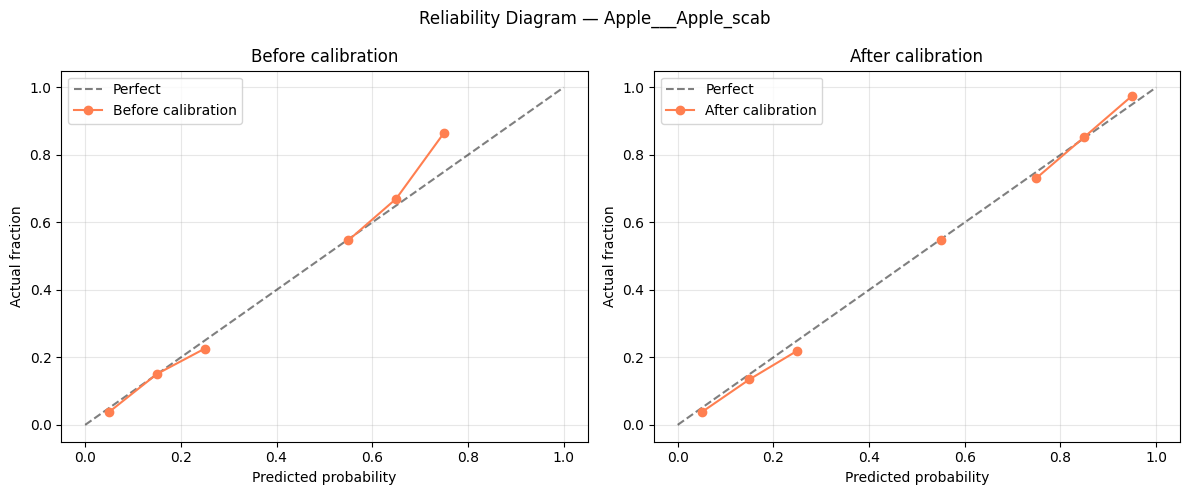

Saved: calibration_plot.png


In [33]:
fusion_model.load_state_dict(
    torch.load('best_fusion.pth', map_location=DEVICE)
)
fusion_model.eval()

# Get raw predictions on test set
# Apply sigmoid here since model head no longer includes it
all_raw_preds, all_true = [], []
with torch.no_grad():
    for X_b, y_b in test_loader_f:
        logits = fusion_model(X_b.to(DEVICE))
        pred   = torch.sigmoid(logits).cpu().numpy()   # convert logits → probs
        all_raw_preds.append(pred)
        all_true.append(y_b.numpy())

raw_preds = np.concatenate(all_raw_preds, axis=0)   # (N_test, 26)
true_vals = np.concatenate(all_true,      axis=0)   # (N_test, 26)

# Fit one isotonic regressor per disease class
calibrators = {}
for i, disease in enumerate(DISEASE_CLASSES):
    ir = IsotonicRegression(out_of_bounds='clip')
    ir.fit(raw_preds[:, i], true_vals[:, i])
    calibrators[disease] = ir

# Calibrated predictions
cal_preds = np.stack(
    [calibrators[d].predict(raw_preds[:, i])
     for i, d in enumerate(DISEASE_CLASSES)],
    axis=1
)

# Compare MAE before/after calibration
raw_mae = mean_absolute_error(true_vals.reshape(-1), raw_preds.reshape(-1))
cal_mae = mean_absolute_error(true_vals.reshape(-1), cal_preds.reshape(-1))
print(f"Test MAE — raw        : {raw_mae:.4f}")
print(f"Test MAE — calibrated : {cal_mae:.4f}")

# Save calibrators
with open('calibrators.pkl', 'wb') as f:
    pickle.dump(calibrators, f)
print("Saved: calibrators.pkl")

# Reliability diagram
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (preds_col, label) in zip(axes, [
    (raw_preds[:, 0], f'Before calibration'),
    (cal_preds[:, 0], f'After calibration'),
]):
    bins     = np.linspace(0, 1, 11)
    bin_idx  = np.digitize(preds_col, bins) - 1
    bin_mean = [true_vals[:, 0][bin_idx == b].mean()
                if (bin_idx == b).sum() > 0 else np.nan
                for b in range(10)]
    bin_mid  = (bins[:-1] + bins[1:]) / 2
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
    ax.plot(bin_mid, bin_mean, 'o-', color='coral', label=label)
    ax.set_xlabel('Predicted probability')
    ax.set_ylabel('Actual fraction')
    ax.set_title(label)
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle(f'Reliability Diagram — {DISEASE_CLASSES[0]}')
plt.tight_layout()
plt.savefig('calibration_plot.png', dpi=150)
plt.show()
print("Saved: calibration_plot.png")

In [34]:
def generate_yield_loss_data(n=8000):
    """
    Generates synthetic yield loss training data.
    Based on FAO and CABI crop loss coefficients.
    """
    np.random.seed(SEED)
 
    # Disease-specific max yield loss coefficients (from literature)
    disease_loss_coeff = {
        'Tomato___Late_blight'                     : 0.80,
        'Potato___Late_blight'                     : 0.75,
        'Tomato___Early_blight'                    : 0.45,
        'Potato___Early_blight'                    : 0.40,
        'Apple___Apple_scab'                       : 0.60,
        'Grape___Black_rot'                        : 0.55,
        'Corn_(maize)___Northern_Leaf_Blight'      : 0.50,
        'Tomato___Bacterial_spot'                  : 0.35,
        'Tomato___Septoria_leaf_spot'              : 0.40,
        'Tomato___Leaf_Mold'                       : 0.35,
        'Squash___Powdery_mildew'                  : 0.30,
        'Cherry_(including_sour)___Powdery_mildew' : 0.30,
        'Corn_(maize)___Common_rust_'              : 0.35,
        'Peach___Bacterial_spot'                   : 0.45,
    }
    default_coeff = 0.25
 
    records = []
    for _ in range(n):
        disease     = np.random.choice(DISEASE_CLASSES)
        coeff       = disease_loss_coeff.get(disease, default_coeff)
        disease_idx = DISEASE_CLASSES.index(disease)
 
        disease_prob   = np.random.beta(2, 3)           # [0, 1]
        severity_score = np.random.beta(1.5, 3)         # [0, 1]
        growth_stage   = np.random.randint(0, 5)        # 0=seedling … 4=mature
        days_to_harvest = np.random.randint(1, 90)
        treatment_applied = np.random.choice([0, 1], p=[0.4, 0.6])
        treatment_delay   = np.random.randint(0, 10) if treatment_applied else 0
 
        # Growth stage multiplier: disease at flowering/fruiting = more damage
        stage_mult = [0.3, 0.6, 1.0, 0.9, 0.5][growth_stage]
 
        # Base yield loss
        base_loss = coeff * disease_prob * severity_score * stage_mult
 
        # Treatment reduces loss
        if treatment_applied:
            efficacy   = max(0, 0.7 - 0.05 * treatment_delay)
            base_loss *= (1 - efficacy)
 
        # Add noise
        yield_loss_pct = np.clip(base_loss + np.random.normal(0, 0.02), 0, 1)
 
        records.append({
            'disease_prob'       : disease_prob,
            'severity_score'     : severity_score,
            'growth_stage'       : growth_stage,
            'days_to_harvest'    : days_to_harvest,
            'treatment_applied'  : treatment_applied,
            'treatment_delay'    : treatment_delay,
            'disease_idx'        : disease_idx,
            'yield_loss_pct'     : yield_loss_pct,
        })
 
    return pd.DataFrame(records)
 
 
yield_df = generate_yield_loss_data(n=8000)
print(f"Yield loss dataset : {yield_df.shape}")
print(yield_df.describe().round(3))
 
# Train XGBoost regressor
feat_cols  = ['disease_prob', 'severity_score', 'growth_stage',
              'days_to_harvest', 'treatment_applied',
              'treatment_delay', 'disease_idx']
X_yield    = yield_df[feat_cols].values
y_yield    = yield_df['yield_loss_pct'].values
 
X_yt, X_yv, y_yt, y_yv = train_test_split(
    X_yield, y_yield, test_size=0.2, random_state=SEED
)
 
xgb_model = xgb.XGBRegressor(
    n_estimators     = 300,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = SEED,
    verbosity        = 0,
)
xgb_model.fit(X_yt, y_yt,
              eval_set=[(X_yv, y_yv)],
              verbose=False)
 
y_pred_yield = xgb_model.predict(X_yv)
print(f"\nYield regressor MAE : {mean_absolute_error(y_yv, y_pred_yield):.4f}")
print(f"Yield regressor R²  : {r2_score(y_yv, y_pred_yield):.4f}")
 
xgb_model.save_model('yield_model.json')
print("Saved: yield_model.json")


Yield loss dataset : (8000, 8)
       disease_prob  severity_score  growth_stage  days_to_harvest  \
count      8000.000        8000.000      8000.000         8000.000   
mean          0.404           0.335         2.019           44.486   
std           0.200           0.200         1.417           25.922   
min           0.004           0.002         0.000            1.000   
25%           0.245           0.172         1.000           22.000   
50%           0.390           0.310         2.000           44.000   
75%           0.545           0.476         3.000           67.000   
max           0.980           0.965         4.000           89.000   

       treatment_applied  treatment_delay  disease_idx  yield_loss_pct  
count           8000.000         8000.000     8000.000        8000.000  
mean               0.606            2.710       12.608           0.027  
std                0.489            3.142        7.528           0.033  
min                0.000            0.000     

In [35]:
INTERVENTIONS = {
    'Tomato___Late_blight': {
        'fungicide'   : 'Mancozeb 75% WP @ 2.5 g/L',
        'frequency'   : 'Every 7 days',
        'timing'      : 'Apply at first sign or when risk > 60%',
        'cost_per_ha' : 800,
        'efficacy_pct': 70,
    },
    'Potato___Late_blight': {
        'fungicide'   : 'Metalaxyl + Mancozeb @ 2.5 g/L',
        'frequency'   : 'Every 7–10 days',
        'timing'      : 'Preventive application when risk > 50%',
        'cost_per_ha' : 900,
        'efficacy_pct': 75,
    },
    'Tomato___Early_blight': {
        'fungicide'   : 'Chlorothalonil 75% WP @ 2 g/L',
        'frequency'   : 'Every 10 days',
        'timing'      : 'Begin when lower leaves show spots',
        'cost_per_ha' : 600,
        'efficacy_pct': 65,
    },
    'Potato___Early_blight': {
        'fungicide'   : 'Mancozeb 75% WP @ 2 g/L',
        'frequency'   : 'Every 10–14 days',
        'timing'      : 'Start at tuber initiation stage',
        'cost_per_ha' : 550,
        'efficacy_pct': 60,
    },
    'Apple___Apple_scab': {
        'fungicide'   : 'Captan 50% WP @ 2.5 g/L',
        'frequency'   : 'Every 7–10 days during wet weather',
        'timing'      : 'Critical period: pink bud to petal fall',
        'cost_per_ha' : 1200,
        'efficacy_pct': 70,
    },
    'Tomato___Bacterial_spot': {
        'fungicide'   : 'Copper oxychloride 50% WP @ 3 g/L',
        'frequency'   : 'Every 7 days',
        'timing'      : 'Apply before or at symptom onset',
        'cost_per_ha' : 700,
        'efficacy_pct': 55,
    },
    'Squash___Powdery_mildew': {
        'fungicide'   : 'Sulphur 80% WP @ 3 g/L',
        'frequency'   : 'Every 10–14 days',
        'timing'      : 'At first sign of white powder on leaves',
        'cost_per_ha' : 400,
        'efficacy_pct': 75,
    },
    'Corn_(maize)___Northern_Leaf_Blight': {
        'fungicide'   : 'Propiconazole 25% EC @ 1 mL/L',
        'frequency'   : 'Every 14 days',
        'timing'      : 'Apply at tasseling stage if risk is high',
        'cost_per_ha' : 750,
        'efficacy_pct': 65,
    },
}
DEFAULT_INTERVENTION = {
    'fungicide'   : 'Consult local agronomist for specific fungicide',
    'frequency'   : 'Every 7–14 days depending on severity',
    'timing'      : 'Apply at first confirmed symptom',
    'cost_per_ha' : 500,
    'efficacy_pct': 50,
}
 
 
def get_intervention(disease_name, risk_score,
                     yield_loss_pct, area_ha=1.0,
                     market_price_per_kg=20.0,
                     expected_yield_kg_per_ha=20000):
    """
    Returns actionable intervention recommendation with ROI calculation.
    """
    rec = INTERVENTIONS.get(disease_name, DEFAULT_INTERVENTION)
 
    # Financial impact
    yield_loss_kg   = expected_yield_kg_per_ha * area_ha * yield_loss_pct
    financial_loss  = yield_loss_kg * market_price_per_kg
    treatment_cost  = rec['cost_per_ha'] * area_ha
    saved_yield_val = financial_loss * (rec['efficacy_pct'] / 100)
    roi             = (saved_yield_val - treatment_cost) / (treatment_cost + 1e-8)
 
    # Risk level
    if risk_score > 0.6:
        urgency = 'TREAT TODAY'
    elif risk_score > 0.3:
        urgency = 'MONITOR CLOSELY — treat within 3 days if worsening'
    else:
        urgency = 'LOW RISK — continue monitoring'
 
    return {
        'disease'           : disease_name,
        'risk_score'        : risk_score,
        'urgency'           : urgency,
        'fungicide'         : rec['fungicide'],
        'frequency'         : rec['frequency'],
        'timing'            : rec['timing'],
        'yield_loss_pct'    : yield_loss_pct,
        'yield_loss_kg'     : yield_loss_kg,
        'financial_loss_inr': financial_loss,
        'treatment_cost_inr': treatment_cost,
        'saved_yield_inr'   : saved_yield_val,
        'roi'               : roi,
    }
 
 
# Demo
demo = get_intervention(
    'Tomato___Late_blight',
    risk_score=0.75,
    yield_loss_pct=0.35,
    area_ha=2.0,
    market_price_per_kg=25.0
)
print("\nIntervention recommendation demo:")
print(f"{'─'*55}")
for k, v in demo.items():
    if isinstance(v, float):
        print(f"  {k:<25} : {v:.2f}")
    else:
        print(f"  {k:<25} : {v}")



Intervention recommendation demo:
───────────────────────────────────────────────────────
  disease                   : Tomato___Late_blight
  risk_score                : 0.75
  urgency                   : TREAT TODAY
  fungicide                 : Mancozeb 75% WP @ 2.5 g/L
  frequency                 : Every 7 days
  timing                    : Apply at first sign or when risk > 60%
  yield_loss_pct            : 0.35
  yield_loss_kg             : 14000.00
  financial_loss_inr        : 350000.00
  treatment_cost_inr        : 1600.00
  saved_yield_inr           : 245000.00
  roi                       : 152.12


In [36]:
def full_inference(image_path, lat, lon,
                   crop_type, growth_stage,
                   days_since_planting, days_to_harvest,
                   area_ha=1.0, market_price_per_kg=20.0,
                   n_mc_passes=50, confidence_threshold=0.45):

    # ── Step 1: CNN inference ──
    raw    = np.array(Image.open(image_path).convert('RGB'))
    tensor = val_transform(image=raw)['image']

    cnn_model.eval()
    with torch.no_grad():
        logits    = cnn_model(tensor.unsqueeze(0).to(DEVICE))
        cnn_probs = logits.softmax(dim=1)[0].cpu().numpy()
        cnn_class = cnn_probs.argmax()
        cnn_conf  = cnn_probs[cnn_class]

    cnn_emb = cnn_model.get_embedding(
        tensor.unsqueeze(0).to(DEVICE)
    ).cpu().numpy()   # (1, 512)

    # ── Step 2: LSTM weather context ──
    weather_df_live = pd.read_csv(
        BASE_DIR / 'weather_features.csv',
        index_col=0, parse_dates=True
    )
    feat      = weather_df_live[WEATHER_FEATURES].values[-LOOKBACK:].astype(np.float32)
    feat_norm = weather_scaler.transform(feat)
    wx_tensor = torch.tensor(feat_norm).unsqueeze(0).to(DEVICE)

    lstm_model.eval()
    with torch.no_grad():
        forecast_raw, wx_ctx, _ = lstm_model(wx_tensor)

    wx_ctx_np    = wx_ctx.cpu().numpy()           # (1, 256)
    forecast_np  = forecast_raw[0].cpu().numpy()  # (7, 26)
    peak_risk_np = forecast_np.max(axis=0)         # (26,)

    # ── Step 3: Metadata encoding ──
    meta = encode_metadata(
        crop_type, growth_stage,
        days_since_planting, days_to_harvest
    ).reshape(1, -1)   # (1, 21)

    # ── Step 4: Fusion input ──
    fusion_input = torch.tensor(
        np.concatenate([cnn_emb, wx_ctx_np, meta], axis=1),
        dtype=torch.float32
    ).to(DEVICE)   # (1, 789)

    # ── Step 5: MC Dropout uncertainty ──
    fusion_model.load_state_dict(
        torch.load('best_fusion.pth', map_location=DEVICE)
    )
    mean_probs, std_probs = fusion_model.predict_with_uncertainty(
        fusion_input, n_passes=n_mc_passes
    )
    mean_probs = mean_probs[0].cpu().numpy()   # (26,)
    std_probs  = std_probs[0].cpu().numpy()    # (26,)

    # ── Step 6: Isotonic calibration ──
    cal_probs = np.array([
        calibrators[d].predict([mean_probs[i]])[0]
        for i, d in enumerate(DISEASE_CLASSES)
    ])

    # ── Step 7: Yield impact ──
    top_disease_idx  = cal_probs.argmax()
    top_disease_name = DISEASE_CLASSES[top_disease_idx]
    top_risk         = cal_probs[top_disease_idx]
    top_uncertainty  = std_probs[top_disease_idx]

    severity = cnn_conf if CLASS_NAMES[cnn_class] == top_disease_name else 0.5

    xgb_features = np.array([[
        top_risk, severity,
        GROWTH_STAGES.index(growth_stage),
        days_to_harvest, 0, 0,
        top_disease_idx
    ]])
    yield_loss_pct = float(xgb_model.predict(xgb_features)[0])

    # ── Step 8: Intervention ──
    intervention = get_intervention(
        top_disease_name, top_risk,
        yield_loss_pct, area_ha, market_price_per_kg
    )

    # ── Print results ──
    print(f"\n{'='*60}")
    print("CROP DISEASE EARLY WARNING — FULL ANALYSIS")
    print(f"{'='*60}")
    print(f"Image            : {Path(image_path).name}")
    print(f"Location         : ({lat}, {lon})")
    print(f"Crop             : {crop_type} ({growth_stage})")

    print(f"\n── CNN Diagnosis ──")
    print(f"  Detected       : {CLASS_NAMES[cnn_class]}")
    print(f"  Confidence     : {cnn_conf:.1%}")
    if cnn_conf < confidence_threshold:
        print(f"  ⚠ Low confidence — retake photo in better lighting")

    print(f"\n── Fusion Risk Assessment (top 5) ──")
    top5_idx = cal_probs.argsort()[::-1][:5]
    for i in top5_idx:
        bar   = '█' * int(cal_probs[i] * 20)
        level = '⚠ HIGH' if cal_probs[i] > 0.6 else 'MOD' if cal_probs[i] > 0.3 else 'LOW'
        print(f"  {DISEASE_CLASSES[i]:<45} "
              f"{cal_probs[i]:.1%} ±{std_probs[i]:.2f}  {bar}  {level}")

    print(f"\n── 7-Day Weather Forecast Risk ──")
    top3_forecast = peak_risk_np.argsort()[::-1][:3]
    for i in top3_forecast:
        print(f"  {DISEASE_CLASSES[i]:<45} peak {peak_risk_np[i]:.1%}")

    print(f"\n── Yield Impact ──")
    print(f"  Top disease    : {top_disease_name}")
    print(f"  Risk score     : {top_risk:.1%} ± {top_uncertainty:.2f}")
    print(f"  Yield loss est : {yield_loss_pct:.1%}")
    print(f"  Financial loss : ₹{intervention['financial_loss_inr']:,.0f}")
    print(f"  Treatment cost : ₹{intervention['treatment_cost_inr']:,.0f}")
    print(f"  Saved value    : ₹{intervention['saved_yield_inr']:,.0f}")
    print(f"  ROI of treating: {intervention['roi']:.1f}x")

    print(f"\n── Intervention ──")
    print(f"  Urgency        : {intervention['urgency']}")
    print(f"  Fungicide      : {intervention['fungicide']}")
    print(f"  Frequency      : {intervention['frequency']}")
    print(f"  Timing         : {intervention['timing']}")
    print(f"{'='*60}")

    return {
        'cnn_class'        : CLASS_NAMES[cnn_class],
        'cnn_confidence'   : float(cnn_conf),
        'top_disease'      : top_disease_name,
        'risk_score'       : float(top_risk),
        'uncertainty'      : float(top_uncertainty),
        'calibrated_probs' : cal_probs.tolist(),
        'forecast_7day'    : forecast_np.tolist(),
        'yield_loss_pct'   : float(yield_loss_pct),
        'intervention'     : intervention,
    }


# ── Run on your real-world test image ──
REAL_WORLD_IMAGE = 'download2.jpg'   # <-- same image from Increment 1

if Path(REAL_WORLD_IMAGE).exists():
    result = full_inference(
        image_path           = REAL_WORLD_IMAGE,
        lat                  = 18.5204,
        lon                  = 73.8567,
        crop_type            = 'Tomato',
        growth_stage         = 'fruiting',
        days_since_planting  = 75,
        days_to_harvest      = 20,
        area_ha              = 1.0,
        market_price_per_kg  = 25.0,
    )
else:
    print(f"Image not found: {REAL_WORLD_IMAGE}")
    print("Set REAL_WORLD_IMAGE to a leaf photo and re-run.")


CROP DISEASE EARLY WARNING — FULL ANALYSIS
Image            : download2.jpg
Location         : (18.5204, 73.8567)
Crop             : Tomato (fruiting)

── CNN Diagnosis ──
  Detected       : Tomato___Early_blight
  Confidence     : 50.7%

── Fusion Risk Assessment (top 5) ──
  Tomato___Early_blight                         45.7% ±0.09  █████████  MOD
  Tomato___Leaf_Mold                            31.7% ±0.05  ██████  MOD
  Grape___Black_rot                             29.3% ±0.07  █████  LOW
  Squash___Powdery_mildew                       27.7% ±0.07  █████  LOW
  Cherry_(including_sour)___Powdery_mildew      27.1% ±0.06  █████  LOW

── 7-Day Weather Forecast Risk ──
  Cherry_(including_sour)___Powdery_mildew      peak 93.6%
  Squash___Powdery_mildew                       peak 81.6%
  Tomato___Tomato_Yellow_Leaf_Curl_Virus        peak 70.8%

── Yield Impact ──
  Top disease    : Tomato___Early_blight
  Risk score     : 45.7% ± 0.09
  Yield loss est : 7.5%
  Financial loss : ₹37,553
  

In [49]:
fusion_model.load_state_dict(torch.load('best_fusion.pth', map_location=DEVICE))
torch.save(fusion_model.state_dict(), 'best_fusion.pth')
 
# Save XGBoost yield model
xgb_model.save_model('yield_model.json')
 
# Save calibrators
with open('calibrators.pkl', 'wb') as f:
    pickle.dump(calibrators, f)
 
# Save fusion config for Increment 4
fusion_config = {
    'fusion_input_dim' : FUSION_INPUT_DIM,
    'hidden_dims'      : [512, 256, 128],
    'n_diseases'       : N_DISEASES,
    'dropout'          : 0.3,
    'disease_classes'  : DISEASE_CLASSES,
    'crop_types'       : CROP_TYPES,
    'growth_stages'    : GROWTH_STAGES,
    'meta_dim'         : META_DIM,
    'confidence_threshold': 0.45,
}
with open('fusion_config.json', 'w') as f:
    json.dump(fusion_config, f, indent=2)
 
print("\n" + "="*60)
print("INCREMENT 3 COMPLETE")
print("Output files:")
print("  best_fusion.pth      ← fusion model weights")
print("  fusion_config.json   ← architecture config for Increment 4")
print("  calibrators.pkl      ← isotonic calibration")
print("  yield_model.json     ← XGBoost yield loss model")
print("  calibration_plot.png ← reliability diagram")
print()
print("FEEDS INTO INCREMENT 4:")
print("  full_inference()     ← end-to-end prediction function")
print("  get_intervention()   ← actionable recommendations + ROI")
print("="*60)


INCREMENT 3 COMPLETE
Output files:
  best_fusion.pth      ← fusion model weights
  fusion_config.json   ← architecture config for Increment 4
  calibrators.pkl      ← isotonic calibration
  yield_model.json     ← XGBoost yield loss model
  calibration_plot.png ← reliability diagram

FEEDS INTO INCREMENT 4:
  full_inference()     ← end-to-end prediction function
  get_intervention()   ← actionable recommendations + ROI


In [50]:
import torch
sd = torch.load('best_fusion.pth', map_location='cpu')
print("Keys OK:", list(sd.keys())[:3])

Keys OK: ['cnn_proj.weight', 'cnn_proj.bias', 'weather_proj.weight']
